# 🎳 Bowling Scoring

Trains **YOLO11n** on a single ~30-second bowling video (small ball + Schweppes-bottle pins with red/green/blue caps), then launches a **Gradio app** that takes a video and returns:
* annotated MP4 with bounding boxes, pin labels (`P1..Pn`), drop chip strip, ball trajectory, top HUD
* JSON drop log with `{label, color, frame, t_abs_s, t_delta_s, x, y}` per drop
* per-pin timing computed from frame PTS

## What's reused vs. new

| Component | Source |
|---|---|
| Pin auto-labeling (HSV color + PCA bbox extension) | reused from Attar Scoring (deterministic, perfect for upright + fallen) |
| Drop detection (cone-vs-body angle + hysteresis) | reused |
| Per-pin timing (frame-PTS based) | reused |
| ByteTrack-lite tracker (greedy IoU + center-distance) | reused, inlined |
| **Ball labels** | hand-curated locally (motion + roundness + temporal continuity + YOLO11x anchors) — uploaded as `ball_labels.zip` |
| Model | **YOLO11n**, `imgsz=480`, transfer-learned from prior `best.pt` if provided |

## 1. Environment + install

In [1]:
!nvidia-smi || echo 'No GPU. Switch runtime: Runtime → Change runtime type → T4 GPU.'
%pip install -q --upgrade pip
%pip install -q ultralytics==8.3.155 opencv-python-headless==4.10.0.84 \
                pillow==10.4.0 gradio==4.44.1 imageio[ffmpeg] tqdm
import ultralytics, torch, cv2, sys
print('Python:', sys.version.split()[0],
      '| Ultralytics:', ultralytics.__version__,
      '| Torch:', torch.__version__,
      '| CUDA:', torch.cuda.is_available(),
      '| OpenCV:', cv2.__version__)

Fri May  8 19:55:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Drive and resolve inputs
Drive layout used by every cell below:
```
/MyDrive/Bowling_Scoring/
├── inputs/
│   ├── bowling.mp4
│   ├── ball_labels.zip       # one .txt per frame; lines: "0 cx cy w h" (ball only)
│   └── best.pt               # optional — previous Attar Scoring weights
├── runs/                     # training checkpoints (Ultralytics writes here)
└── release/                  # final exports
```

In [2]:
import os, shutil, glob
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT    = '/content/drive/MyDrive/Bowling_Scoring'
DRIVE_INPUTS  = f'{DRIVE_ROOT}/inputs'
DRIVE_RUNS    = f'{DRIVE_ROOT}/runs'
DRIVE_RELEASE = f'{DRIVE_ROOT}/release'
for p in (DRIVE_RUNS, DRIVE_RELEASE): os.makedirs(p, exist_ok=True)

VIDEO_PATH         = f'{DRIVE_INPUTS}/bowling.mp4'
BALL_LABELS_ZIP    = f'{DRIVE_INPUTS}/ball_labels.zip'
PRIOR_WEIGHTS_PATH = f'{DRIVE_INPUTS}/best.pt'

missing = [p for p in (VIDEO_PATH, BALL_LABELS_ZIP) if not os.path.exists(p)]
assert not missing, (
    'Missing required input(s) in Drive: ' + ', '.join(missing) +
    f'\n→ Place them under {DRIVE_INPUTS} and re-run this cell.'
)
PRIOR_WEIGHTS = PRIOR_WEIGHTS_PATH if os.path.exists(PRIOR_WEIGHTS_PATH) else None
print('Video:           ', VIDEO_PATH, f'({os.path.getsize(VIDEO_PATH)//1024//1024} MB)')
print('Ball labels zip: ', BALL_LABELS_ZIP)
print('Prior weights:   ', PRIOR_WEIGHTS or '(none — will start from yolo11n COCO)')

Mounted at /content/drive
Video:            /content/drive/MyDrive/Bowling_Scoring/inputs/bowling.mp4 (30 MB)
Ball labels zip:  /content/drive/MyDrive/Bowling_Scoring/inputs/ball_labels.zip
Prior weights:    /content/drive/MyDrive/Bowling_Scoring/inputs/best.pt


## 3. Extract frames at 5 fps
Same rate used during ball labeling, so the filenames line up 1:1 with `ball_labels.zip`.

In [3]:
import os, glob, subprocess, cv2
FRAMES_DIR = '/content/frames'
os.makedirs(FRAMES_DIR, exist_ok=True)
subprocess.run([
    'ffmpeg', '-y', '-loglevel', 'error', '-i', VIDEO_PATH,
    '-vf', 'fps=5,scale=960:-2', '-q:v', '3',
    f'{FRAMES_DIR}/f_%04d.jpg',
], check=True)
FRAMES = sorted(glob.glob(f'{FRAMES_DIR}/*.jpg'))
h, w = cv2.imread(FRAMES[0]).shape[:2]
print(f'Extracted {len(FRAMES)} frames at {w}x{h}')

Extracted 183 frames at 960x960


## 4. Pin auto-labeling — HSV color + PCA principal-axis bbox extension
Reused from Attar Scoring. For each colored cone (red/green/blue) we:
1. Threshold HSV to get the cone mask.
2. Connected components → keep blobs in plausible size + aspect ratio.
3. PCA on each blob → principal-axis direction.
4. Extend bbox 2.2× along that axis to cover the (transparent) bottle body.

Works identically for **standing** AND **fallen** pins because the principal axis simply rotates.

In [4]:
import cv2, numpy as np

# Class IDs
CLS_BALL, CLS_RED, CLS_GREEN, CLS_BLUE = 0, 1, 2, 3

HSV_RANGES = {
    CLS_RED:   [((0, 110, 70),   (8, 255, 255)),
                ((172, 110, 70), (180, 255, 255))],
    CLS_GREEN: [((38, 70, 50),   (85, 255, 255))],
    CLS_BLUE:  [((95, 90, 60),   (130, 255, 255))],
}

def detect_pins(bgr):
    """Return list of (cls, x1, y1, x2, y2) for upright AND fallen pins."""
    H, W = bgr.shape[:2]
    img_area = H * W
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    out = []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    for cls, ranges in HSV_RANGES.items():
        m = np.zeros(hsv.shape[:2], dtype=np.uint8)
        for lo, hi in ranges:
            m |= cv2.inRange(hsv, np.array(lo, dtype=np.uint8),
                                  np.array(hi, dtype=np.uint8))
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=2)
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kernel, iterations=1)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(m, 8)
        for i in range(1, n):
            x, y, ww, hh, area = stats[i]
            if area < max(150, img_area * 0.00012) or area > img_area * 0.04: continue
            ar = max(ww, hh) / max(1, min(ww, hh))
            if ar > 4.0: continue
            ys, xs = np.where(labels == i)
            if len(xs) < 30: continue
            pts = np.column_stack([xs.astype(np.float32), ys.astype(np.float32)])
            mean, eigvecs, _ = cv2.PCACompute2(pts, np.empty(0))
            cx, cy = float(mean[0, 0]), float(mean[0, 1])
            mx, my = float(eigvecs[0, 0]), float(eigvecs[0, 1])
            nrm = (mx * mx + my * my) ** 0.5 or 1.0
            mx /= nrm; my /= nrm
            L = max(ww, hh); ext = 2.2 * L
            xs_b = [x, x + ww, cx - mx * ext, cx + mx * ext]
            ys_b = [y, y + hh, cy - my * ext, cy + my * ext]
            x1 = max(0, int(min(xs_b))); y1 = max(0, int(min(ys_b)))
            x2 = min(W, int(max(xs_b))); y2 = min(H, int(max(ys_b)))
            if x2 - x1 < 10 or y2 - y1 < 10: continue
            out.append((cls, x1, y1, x2, y2))
    return out

## 5. Load the pre-made ball labels
Each `.txt` contains zero or one line in YOLO format: `0 cx cy w h` (normalized).
If a frame has no ball visible, the file is empty — that's expected.

In [5]:
import zipfile
BALL_DIR = '/content/ball_labels'
if os.path.isdir(BALL_DIR): shutil.rmtree(BALL_DIR)
os.makedirs(BALL_DIR)
with zipfile.ZipFile(BALL_LABELS_ZIP) as z:
    z.extractall(BALL_DIR)
# zip may flatten or nest one level deep — find the real root
txt_files = glob.glob(f'{BALL_DIR}/**/*.txt', recursive=True)
if not txt_files:
    raise RuntimeError('ball_labels.zip contains no .txt files')
BALL_LABEL_ROOT = os.path.dirname(txt_files[0])
n_ball_with_box = sum(1 for f in txt_files if os.path.getsize(f) > 0)
print(f'Ball-label .txt files: {len(txt_files)}  (of which {n_ball_with_box} contain a box)')
print(f'Resolved root: {BALL_LABEL_ROOT}')

Ball-label .txt files: 183  (of which 20 contain a box)
Resolved root: /content/ball_labels


## 6. Visual sanity check

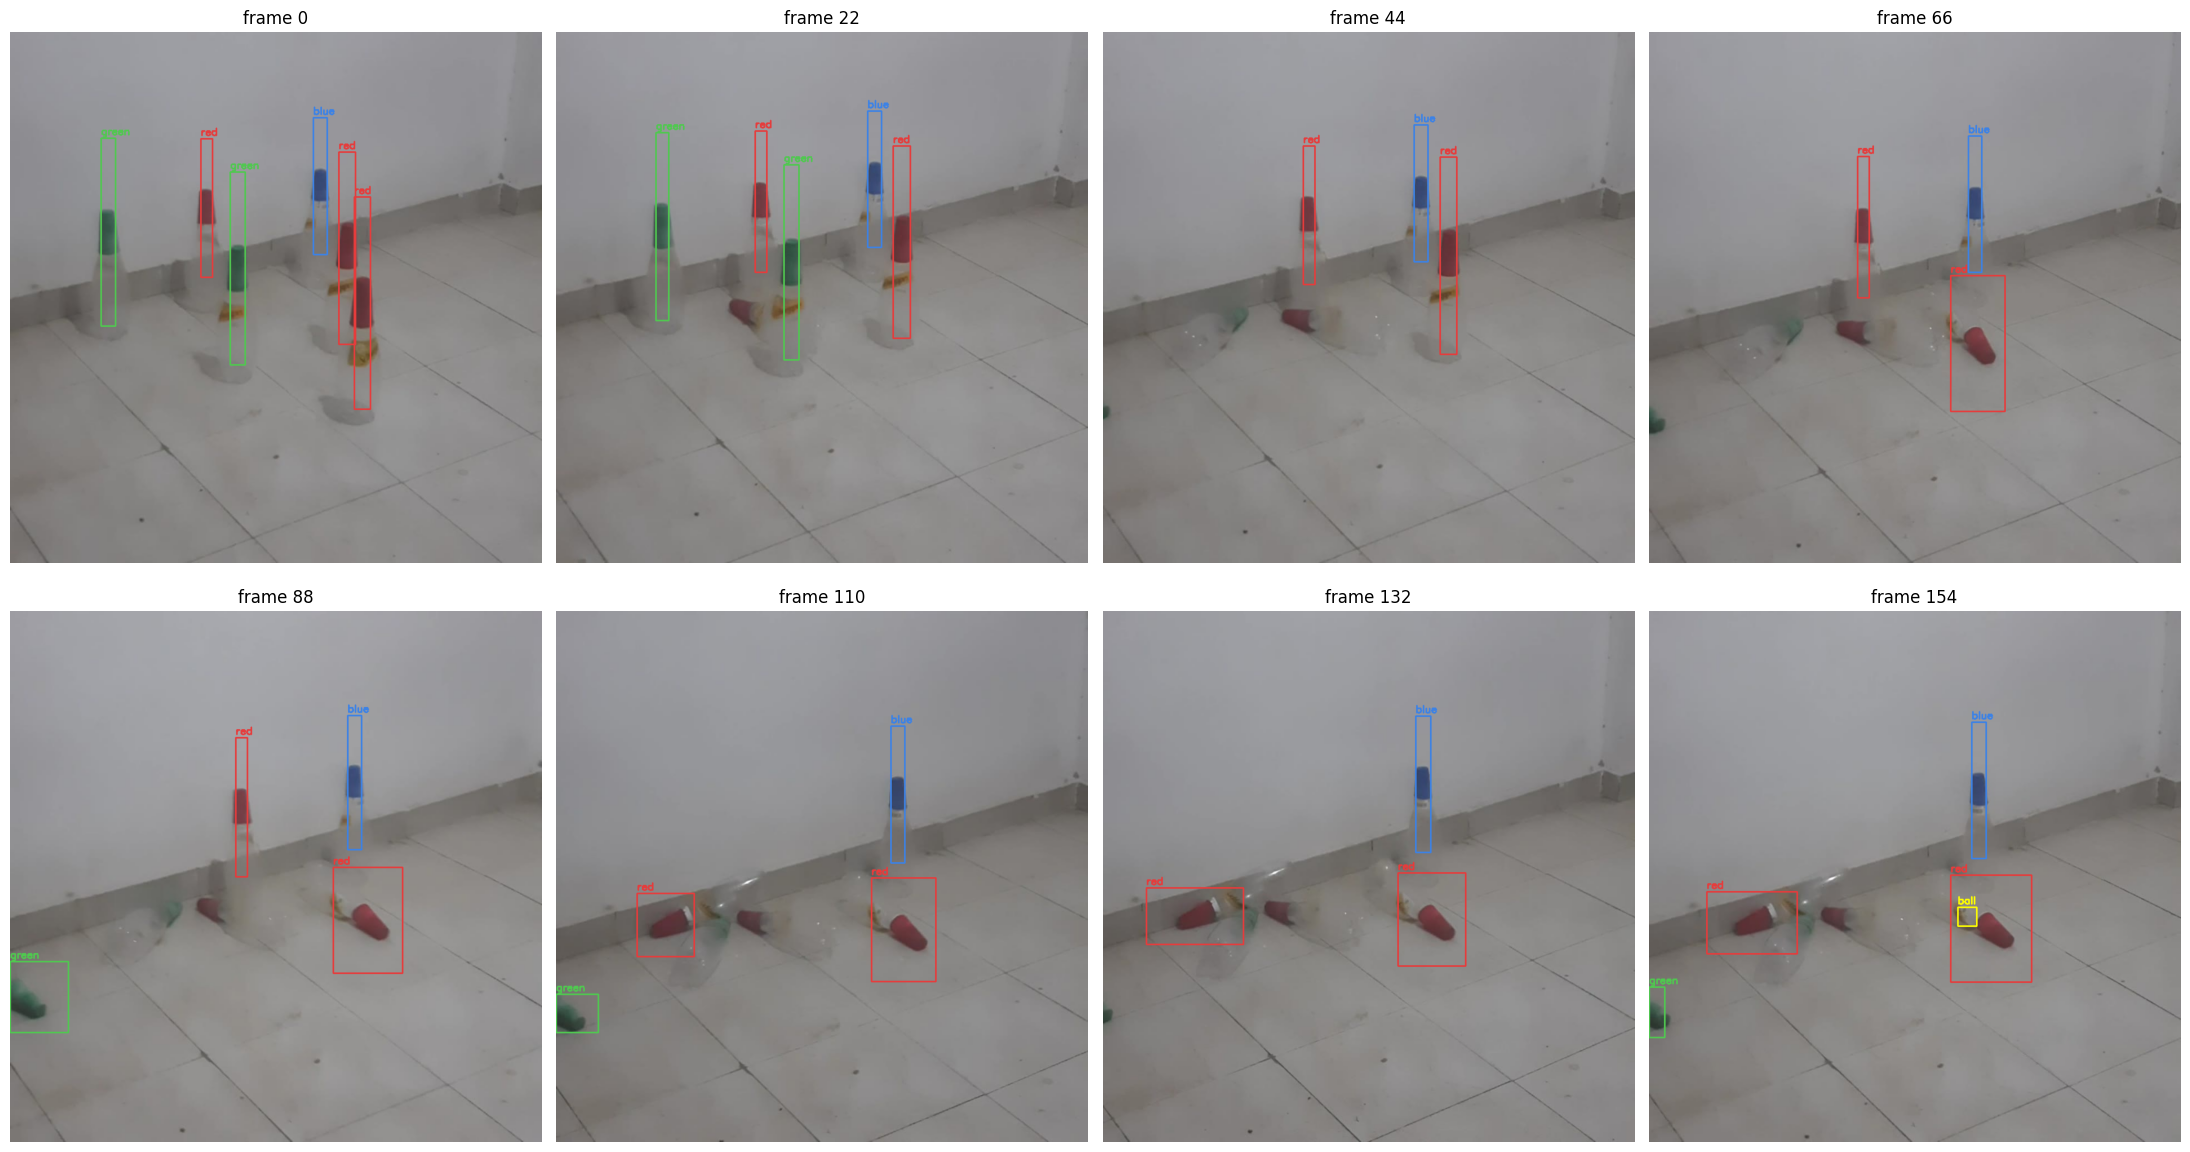

In [6]:
import matplotlib.pyplot as plt

COLOR_BGR = {CLS_BALL: (255, 255, 255), CLS_RED: (60, 60, 230),
             CLS_GREEN: (80, 200, 80), CLS_BLUE: (230, 130, 60)}
NAME = {CLS_BALL: 'ball', CLS_RED: 'red', CLS_GREEN: 'green', CLS_BLUE: 'blue'}

def load_ball_box(frame_path, W, H):
    bn = os.path.splitext(os.path.basename(frame_path))[0]
    p = os.path.join(BALL_LABEL_ROOT, bn + '.txt')
    if not os.path.exists(p) or os.path.getsize(p) == 0:
        return None
    parts = open(p).read().split()
    if len(parts) < 5: return None
    _, cx, cy, w, h = [float(x) for x in parts[:5]]
    x1 = int((cx - w/2) * W); y1 = int((cy - h/2) * H)
    x2 = int((cx + w/2) * W); y2 = int((cy + h/2) * H)
    return (x1, y1, x2, y2)

sample_idx = list(range(0, len(FRAMES), max(1, len(FRAMES)//8)))[:8]
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
for ax, i in zip(axes.flat, sample_idx):
    img = cv2.imread(FRAMES[i]); H, W = img.shape[:2]
    for cls, x1, y1, x2, y2 in detect_pins(img):
        cv2.rectangle(img, (x1, y1), (x2, y2), COLOR_BGR[cls], 2)
        cv2.putText(img, NAME[cls], (x1, max(0, y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_BGR[cls], 2)
    bb = load_ball_box(FRAMES[i], W, H)
    if bb is not None:
        cv2.rectangle(img, (bb[0], bb[1]), (bb[2], bb[3]), (0, 255, 255), 2)
        cv2.putText(img, 'ball', (bb[0], max(0, bb[1]-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'frame {i}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Build YOLO dataset (cross-temporal split)
First 70 % of frames → train, middle 15 % → val, last 15 % → test. No temporal leakage; the test split is the **end of the run** which is exactly what we'd care about for scoring fidelity.

In [7]:
DSET = '/content/bowl_dataset'
if os.path.isdir(DSET): shutil.rmtree(DSET)
for sub in ['images/train', 'images/val', 'images/test',
            'labels/train', 'labels/val', 'labels/test']:
    os.makedirs(f'{DSET}/{sub}')

def yolo_line(cls, x1, y1, x2, y2, W, H):
    cx = (x1 + x2) / 2.0 / W
    cy = (y1 + y2) / 2.0 / H
    w  = (x2 - x1) / W
    h  = (y2 - y1) / H
    return f'{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}'

n_total = len(FRAMES)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
def split_for(i):
    if i < n_train:           return 'train'
    if i < n_train + n_val:   return 'val'
    return 'test'

from collections import Counter
class_counts = Counter()
for i, p in enumerate(FRAMES):
    img = cv2.imread(p); H, W = img.shape[:2]
    pins = detect_pins(img)
    lines = [yolo_line(c, x1, y1, x2, y2, W, H) for (c, x1, y1, x2, y2) in pins]
    bb = load_ball_box(p, W, H)
    if bb is not None:
        lines.append(yolo_line(CLS_BALL, *bb, W, H))
    for ln in lines: class_counts[int(ln.split()[0])] += 1
    sp = split_for(i)
    bn = os.path.basename(p)
    shutil.copy(p, f'{DSET}/images/{sp}/{bn}')
    open(f'{DSET}/labels/{sp}/{os.path.splitext(bn)[0]}.txt', 'w').write('\n'.join(lines))

for sp in ('train', 'val', 'test'):
    print(f'{sp:>5}: {len(os.listdir(f"{DSET}/images/{sp}"))} frames')
print('per-class box counts:', dict(class_counts), '(0=ball, 1=red, 2=green, 3=blue)')

open(f'{DSET}/data.yaml', 'w').write(
    'path: /content/bowl_dataset\n'
    'train: images/train\nval: images/val\ntest: images/test\n'
    'names:\n  0: ball\n  1: pin_red\n  2: pin_green\n  3: pin_blue\n')
!cat {DSET}/data.yaml

train: 128 frames
  val: 27 frames
 test: 28 frames
per-class box counts: {1: 373, 2: 129, 3: 181, 0: 20} (0=ball, 1=red, 2=green, 3=blue)
path: /content/bowl_dataset
train: images/train
val: images/val
test: images/test
names:
  0: ball
  1: pin_red
  2: pin_green
  3: pin_blue


## 8. Train YOLO11n — Phase 1 (frozen backbone, head warm-up)
Transfer-learns from the previous Attar Scoring `best.pt` if you uploaded it. Pin classes (1/2/3) are identical between projects, so only class 0 (`car`→`ball`) needs to relearn — phase 1 with a frozen backbone gets the head to a good starting point fast.

Crash-proof: writes a checkpoint every 5 epochs into Drive at `/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen/weights/`. If the runtime disconnects, just re-run this cell — it auto-resumes from `last.pt`.

In [8]:
from ultralytics import YOLO
BASE = PRIOR_WEIGHTS if PRIOR_WEIGHTS else 'yolo11n.pt'
print('Phase 1 base weights:', BASE)

P1_NAME = 'bowl_phase1_frozen'
p1_dir  = f'{DRIVE_RUNS}/{P1_NAME}'
last1   = f'{p1_dir}/weights/last.pt'
model = YOLO(last1) if os.path.exists(last1) else YOLO(BASE)

model.train(
    data=f'{DSET}/data.yaml',
    epochs=20, imgsz=480, batch=16,
    optimizer='AdamW', lr0=1e-3, weight_decay=5e-4,
    warmup_epochs=3, cos_lr=True, label_smoothing=0.05,
    # Strong domain randomization (tiny dataset, single video).
    mosaic=1.0, mixup=0.15, copy_paste=0.30,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.5,
    degrees=15, translate=0.1, scale=0.6, shear=2.0, perspective=0.0008,
    fliplr=0.5, erasing=0.4,
    dropout=0.1,
    freeze=10,
    project=DRIVE_RUNS, name=P1_NAME, exist_ok=True,
    save_period=5, resume=os.path.exists(last1),
    patience=10, device=0,
)
best_p1 = f'{p1_dir}/weights/best.pt'
print('Phase 1 done →', best_p1)

Phase 1 base weights: /content/drive/MyDrive/Bowling_Scoring/inputs/best.pt
New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/bowl_dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_d

100%|██████████| 755k/755k [00:00<00:00, 115MB/s]


                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

YOLO11n summary: 181 layers, 2,590,620 parameters, 2,590,604 gradients, 6.4 GFLOPs

Transferred 499/499 items from pretrained weights
Freezing layer 'model.0.conv.weight'
Freezing layer 'model.0.bn.weight'
Freezing layer 'model.0.bn.bias'
Freezing layer 'model.1.conv.weight'
Freezing layer 'model.1.bn.weight'
Freezing layer 'model.1.bn.bias'
Freezing layer 'model.2.cv1.conv.weight'
Freezing layer 'model.2.cv1.bn.weight'
Freezing layer 'model.2.cv1.bn.bias'
Freezing layer 'model.2.cv2.conv.weight'
Freezing layer 'model.2.cv2.bn.weight'
Freezing layer 'model.2.cv2.bn.bias'
Freezing layer 'model.2.m.0.cv1.conv.weight'
Freezing layer 'model.2.m.0.cv1.bn.weight'
Freezing layer 'model.2.m.0.cv1.bn.bias'
Freezing layer 'model.2.m.0.cv2.conv.weight'
Freezing layer 'model.2.m.0.cv2.bn.weight'
Freezing layer 'model.2.m.0.cv2.bn.bias'
Freezing layer 'model.3.conv.weight'
Freezing layer 'model.3.bn.weight'
Freezing layer 'model.3.bn.bias'
Freezing layer 'model.4.cv1.conv.weight'
Freezing layer 'mo

100%|██████████| 5.35M/5.35M [00:00<00:00, 350MB/s]


...

      20/20     0.979G      1.074     0.7149      1.195         60        480: 100%|██████████| 8/8 [00:01<00:00,  5.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.59it/s]

                   all         27        100      0.861      0.596      0.592      0.262



20 epochs completed in 0.020 hours.
Optimizer stripped from /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen/weights/last.pt, 5.4MB
Optimizer stripped from /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen/weights/best.pt, 5.4MB

Validating /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen/weights/best.pt...
Ultralytics 8.3.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.31it/s]
Exception in thread Thread-25 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 842, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _

                   all         27        100       0.86      0.596      0.593      0.261
                  ball          6          6          1          0      0.094     0.0291
               pin_red         27         53      0.933      0.962      0.948      0.505
             pin_green         14         14      0.638      0.571      0.543     0.0972
              pin_blue         27         27       0.87      0.852      0.787      0.414
Speed: 0.1ms preprocess, 1.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen
Phase 1 done → /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase1_frozen/weights/best.pt


## 9. Train YOLO11n — Phase 2 (unfreeze, full fine-tune)
Same crash-proof pattern.

In [9]:
P2_NAME = 'bowl_phase2_full'
p2_dir  = f'{DRIVE_RUNS}/{P2_NAME}'
last2   = f'{p2_dir}/weights/last.pt'
model = YOLO(last2) if os.path.exists(last2) else YOLO(best_p1)

model.train(
    data=f'{DSET}/data.yaml',
    epochs=80, imgsz=480, batch=16,
    optimizer='AdamW', lr0=5e-4, weight_decay=5e-4,
    warmup_epochs=2, cos_lr=True, label_smoothing=0.05,
    mosaic=1.0, mixup=0.10, copy_paste=0.30,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.5,
    degrees=15, translate=0.1, scale=0.6, shear=2.0, perspective=0.0008,
    fliplr=0.5, erasing=0.4,
    dropout=0.1,
    freeze=0,
    project=DRIVE_RUNS, name=P2_NAME, exist_ok=True,
    save_period=5, resume=os.path.exists(last2),
    patience=20, device=0,
)
BEST = f'{p2_dir}/weights/best.pt'
print('Final best →', BEST)

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/bowl_dataset/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/Bowling_Scoring/

train: Scanning /content/bowl_dataset/labels/train.cache... 128 images, 0 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 189.7±32.6 MB/s, size: 20.1 KB)


val: Scanning /content/bowl_dataset/labels/val.cache... 27 images, 0 backgrounds, 0 corrupt: 100%|██████████| 27/27 [00:00<?, ?it/s]


...

      80/80      1.44G      0.899     0.5746      1.086         59        480: 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  5.00it/s]

                   all         27        100      0.691      0.692      0.699      0.337



80 epochs completed in 0.065 hours.
Optimizer stripped from /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase2_full/weights/last.pt, 5.5MB
Optimizer stripped from /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase2_full/weights/best.pt, 5.5MB

Validating /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase2_full/weights/best.pt...
Ultralytics 8.3.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.11it/s]
Exception in thread Thread-37 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 842, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _

                   all         27        100      0.914      0.557      0.667      0.397
                  ball          6          6          1          0      0.255     0.0659
               pin_red         27         53      0.935      0.962       0.97      0.641
             pin_green         14         14      0.852      0.413      0.576      0.216
              pin_blue         27         27      0.869      0.852      0.866      0.664
Speed: 0.2ms preprocess, 1.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase2_full
Final best → /content/drive/MyDrive/Bowling_Scoring/runs/bowl_phase2_full/weights/best.pt


## 10. Evaluate on the held-out tail

In [10]:
model = YOLO(BEST)
metrics = model.val(data=f'{DSET}/data.yaml', split='test', imgsz=480, save_json=True)
print(metrics.results_dict)

Ultralytics 8.3.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 534.4±141.9 MB/s, size: 20.4 KB)


val: Scanning /content/bowl_dataset/labels/test... 28 images, 0 backgrounds, 0 corrupt: 100%|██████████| 28/28 [00:00<00:00, 1616.41it/s]

val: New cache created: /content/bowl_dataset/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  50%|█████     | 1/2 [00:00<00:00,  2.80it/s]Exception in thread Thread-45 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 842, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _

                   all         28        107      0.725      0.929      0.787      0.445
                  ball          3          3      0.499          1      0.497      0.183
               pin_red         28         56      0.988          1      0.995      0.669
             pin_green         22         22      0.602      0.909      0.826      0.313
              pin_blue         26         26       0.81      0.808      0.827      0.614
Speed: 3.3ms preprocess, 21.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
{'metrics/precision(B)': np.float64(0.7247832480631419), 'metrics/recall(B)': np.float64(0.9291958041958042), 'metrics/mAP50(B)': np.float64(0.7865753359631525), 'metrics/mAP50-95(B)': np.float64(0.4447414406857987), 'fitness': np.float64(0.4789248302135341)}


## 11. Mirror the trained weights to Drive

In [11]:
import shutil
shutil.copy(BEST, f'{DRIVE_RELEASE}/best.pt')
print('Mirrored →', f'{DRIVE_RELEASE}/best.pt')

Mirrored → /content/drive/MyDrive/Bowling_Scoring/release/best.pt


## 12. Gradio app — video in → annotated video + drop log
Frame-by-frame pipeline:
* YOLO11n inference at `imgsz=480`
* ByteTrack-lite tracker (greedy IoU + center-distance, color-class anchored re-binding)
* Pin labelling (`P1..Pn`, deterministic top-to-bottom + left-to-right at first sighting)
* Drop detection: pin bbox aspect ratio drops below 0.85 for ≥ 6 consecutive frames (with 30-frame release hysteresis)
* Per-pin timing from `frame_index / fps`
* Burns into the output MP4: bboxes + label pills, drop chip strip (last 6 drops), ball trajectory polyline (fading), top HUD (drop count + elapsed time)
* Returns: annotated video + JSON drop log + plain-English summary

The cell launches Gradio with a public **share** link — open in any browser, drop a video, get the annotated output.

In [14]:
!pip install --upgrade gradio huggingface_hub
import json, math, tempfile
from collections import deque
import gradio as gr
import numpy as np, cv2
from ultralytics import YOLO
 BEST = "/content/drive/MyDrive/Bowling_Scoring/release/best.pt"
_MODEL_PATH = BEST  # change to a Drive path to use a different checkpoint
_model = YOLO(_MODEL_PATH)

PIN_BGR  = {1: (60, 60, 230), 2: (80, 200, 80), 3: (230, 130, 60)}
PIN_NM   = {1: 'RED', 2: 'GREEN', 3: 'BLUE'}
BALL_BGR = (255, 255, 255)
DROP_CONFIRM_FRAMES = 6
DROP_RELEASE_FRAMES = 30

def fmt_t(seconds):
    m = int(seconds // 60); s = int(seconds) % 60
    ms = int((seconds - int(seconds)) * 1000)
    return f'{m:02d}:{s:02d}.{ms:03d}'

def iou(a, b):
    ax1,ay1,ax2,ay2 = a; bx1,by1,bx2,by2 = b
    iw = max(0, min(ax2,bx2) - max(ax1,bx1))
    ih = max(0, min(ay2,by2) - max(ay1,by1))
    inter = iw * ih
    if inter == 0: return 0
    return inter / ((ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter)

def center(b): return ((b[0]+b[2])/2, (b[1]+b[3])/2)

class Track:
    __slots__ = ('id','cls','box','score','age','hits','missed','label')
    def __init__(self, tid, cls, box, score):
        self.id=tid; self.cls=cls; self.box=box; self.score=score
        self.age=1; self.hits=1; self.missed=0; self.label=None

class Tracker:
    def __init__(self): self._n=1; self.tracks=[]
    def update(self, dets):
        used = [False]*len(dets)
        for t in self.tracks:
            best_j=-1; best_cost=1e9
            for j,(cls,conf,box) in enumerate(dets):
                if used[j] or cls!=t.cls: continue
                io = iou(t.box, box); d = math.dist(center(t.box), center(box))
                if io < 0.30 and d > 80: continue
                cost = (1-io)*100 + d
                if cost < best_cost: best_cost=cost; best_j=j
            if best_j >= 0:
                cls,conf,box = dets[best_j]; used[best_j]=True
                t.box=box; t.score=conf; t.hits+=1; t.missed=0; t.age+=1
            else:
                t.missed+=1; t.age+=1
        self.tracks = [t for t in self.tracks if t.missed <= 15]
        for j,(cls,conf,box) in enumerate(dets):
            if used[j]: continue
            self.tracks.append(Track(self._n, cls, box, conf)); self._n += 1

def is_pin_fallen(box):
    h = box[3]-box[1]; w = max(1, box[2]-box[0])
    return (h/w) < 0.85

def analyze(input_path, conf_thresh=0.35, progress=gr.Progress()):
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out_path = tempfile.NamedTemporaryFile(suffix='.mp4', delete=False).name
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

    tracker = Tracker()
    next_pin_idx = 1
    fallen_count, standing_count = {}, {}
    dropped = set()
    drops, last_drop_t = [], None
    ball_path = deque(maxlen=400)

    fi = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        res = _model.predict(frame, imgsz=480, conf=conf_thresh, verbose=False, device=0)[0]
        dets = []
        if res.boxes is not None:
            for cls, conf, box in zip(
                res.boxes.cls.cpu().numpy().astype(int),
                res.boxes.conf.cpu().numpy(),
                res.boxes.xyxy.cpu().numpy().astype(int)):
                dets.append((int(cls), float(conf), tuple(box.tolist())))
        tracker.update(dets)

        # assign pin labels in deterministic order
        new_pins = [t for t in tracker.tracks if t.cls in (1,2,3) and t.label is None]
        new_pins.sort(key=lambda t: (t.box[1], t.box[0]))
        for t in new_pins:
            t.label = f'P{next_pin_idx}'; next_pin_idx += 1

        # ball path
        balls = sorted([t for t in tracker.tracks if t.cls==0], key=lambda t:-t.score)
        if balls:
            cx, cy = center(balls[0].box)
            if not ball_path or ((cx-ball_path[-1][0])**2+(cy-ball_path[-1][1])**2)**0.5 > 4:
                ball_path.append((cx, cy))

        # drop detection
        t_abs = fi / fps
        for t in tracker.tracks:
            if t.cls not in (1,2,3): continue
            if is_pin_fallen(t.box):
                fallen_count[t.id] = fallen_count.get(t.id,0) + 1
                standing_count[t.id] = 0
            else:
                standing_count[t.id] = standing_count.get(t.id,0) + 1
                if standing_count[t.id] > DROP_RELEASE_FRAMES:
                    dropped.discard(t.id); fallen_count[t.id] = 0
            if fallen_count.get(t.id,0) >= DROP_CONFIRM_FRAMES and t.id not in dropped:
                dropped.add(t.id)
                t_delta = t_abs if last_drop_t is None else (t_abs - last_drop_t)
                last_drop_t = t_abs
                drops.append({
                    'label': t.label or '?', 'colorClass': int(t.cls),
                    'frame': fi, 't_abs_s': round(t_abs,3), 't_delta_s': round(t_delta,3),
                    'x': float(center(t.box)[0]), 'y': float(center(t.box)[1]),
                })

        # render
        out = frame.copy()
        bp = list(ball_path)
        for k in range(1, len(bp)):
            a = k / max(1, len(bp))
            cv2.line(out, (int(bp[k-1][0]),int(bp[k-1][1])),
                          (int(bp[k][0]),  int(bp[k][1])),
                          (0, int(200*a+30), int(255*a)), 3)
        for t in tracker.tracks:
            x1,y1,x2,y2 = t.box
            if t.cls == 0:
                col = BALL_BGR; lab = f'BALL {t.score*100:.0f}%'
            else:
                col = PIN_BGR.get(t.cls,(255,255,255))
                lab = f'{t.label or "·"}  {PIN_NM.get(t.cls,"?")}  {t.score*100:.0f}%'
            cv2.rectangle(out,(x1,y1),(x2,y2), col, 2)
            (tw,th),_ = cv2.getTextSize(lab, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(out,(x1, max(0,y1-th-8)), (x1+tw+8, max(th+8,y1)), col, -1)
            cv2.putText(out, lab, (x1+4, max(th+3, y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
        chip_y = H - 90
        for k, d in enumerate(drops[-6:]):
            cx0 = 16 + k*240
            cv2.rectangle(out,(cx0,chip_y),(cx0+220,chip_y+74),(15,15,15),-1)
            cv2.rectangle(out,(cx0,chip_y),(cx0+220,chip_y+74),PIN_BGR[d['colorClass']],2)
            cv2.putText(out, d['label'], (cx0+10,chip_y+30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9,(255,255,255),2)
            cv2.putText(out, fmt_t(d['t_abs_s']), (cx0+10,chip_y+55),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55,(255,255,255),1)
            cv2.putText(out, f'+{fmt_t(d["t_delta_s"])}', (cx0+10,chip_y+71),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,PIN_BGR[d['colorClass']],1)
        cv2.rectangle(out,(12,12),(260,56),(0,0,0),-1)
        cv2.putText(out, f'Drops {len(drops)} | t {fmt_t(t_abs)}',
                    (20,42), cv2.FONT_HERSHEY_SIMPLEX, 0.7,(255,255,255), 2)

        writer.write(out); fi += 1
        if fi % 5 == 0: progress(fi / max(1, n_frames), desc='Analyzing')

    cap.release(); writer.release()

    json_path = tempfile.NamedTemporaryFile(suffix='.json', delete=False).name
    with open(json_path,'w') as f:
        json.dump({'drops':drops,'fps':fps,'frames':fi,
                   'totals':{'pins_dropped':len(drops)}}, f, indent=2)
    summary = (f'Analyzed {fi} frames at {fps:.1f} fps.\nPins dropped: {len(drops)}.\n' +
               '\n'.join(f"{d['label']} ({PIN_NM[d['colorClass']]}) @ {fmt_t(d['t_abs_s'])}  +{fmt_t(d['t_delta_s'])}"
                         for d in drops))
    return out_path, json_path, summary

with gr.Blocks(title='🎳 Bowling Scoring', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🎳 Bowling Scoring\nUpload a gameplay video. The model detects ball + pins, '
                'tracks each pin, scores drops in sequence with per-pin timing, and overlays '
                'everything on the output video.')
    with gr.Row():
        inp = gr.Video(label='Input video', height=360)
        with gr.Column():
            out_vid  = gr.Video(label='Annotated output', height=360)
            out_json = gr.File(label='Drop log (JSON)')
            out_text = gr.Textbox(label='Summary', lines=12)
    conf = gr.Slider(0.10, 0.80, 0.35, step=0.05, label='Confidence threshold')
    btn = gr.Button('Analyze', variant='primary')
    btn.click(analyze, [inp, conf], [out_vid, out_json, out_text])

demo.launch(share=True, debug=False)

IndentationError: unexpected indent (2361841896.py, line 7)